# Tugas Besar: Implementasi Neural Network from Scratch
## Klasifikasi Dry Bean Dataset

Mata Kuliah: Kecerdasan Buatan  
Universitas Darunnajah 2025/2026  
Nama: Ahmad Aqil Almutashim  
NIM: 2403049028

---

## Daftar Isi
1. Import Library & Load Dataset
2. Preprocessing Data
3. Implementasi ANN from Scratch (Weight Init, Activation, Loss, Forward, Backward)
4. Eksperimen 1: Variasi Arsitektur
5. Eksperimen 2: Variasi Inisialisasi Bobot
6. Eksperimen 3: Variasi Fungsi Aktivasi
7. Eksperimen 4: Variasi Learning Rate
8. Eksperimen 5: Variasi Batch Size
9. Eksperimen 6: Variasi Jumlah Epoch
10. Implementasi dengan Keras
11. Perbandingan dengan Sklearn

## 1. Import Library & Load Dataset

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_excel('Dry_Bean_Dataset.xlsx')

# Cek dataset
print("Shape:", df.shape)
print("\n5 data pertama:")
print(df.head())
print("\nKolom:", df.columns.tolist())
print("\nJumlah tiap kelas:")
print(df['Class'].value_counts())

Shape: (13611, 17)

5 data pertama:
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272750  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Cl

## 2. Preprocessing Data
Memisahkan fitur & label, encoding label, normalisasi, dan split data train-test.

In [50]:
# 1. Pisahkan fitur (X) dan label (y)
X = df.drop('Class', axis=1).values
y = df['Class'].values

print("Shape X:", X.shape)  # (13611, 16)
print("Shape y:", y.shape)  # (13611,)
print("Kelas unik:", np.unique(y))

Shape X: (13611, 16)
Shape y: (13611,)
Kelas unik: ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']


In [51]:
from sklearn.preprocessing import LabelEncoder

# 2. Encode label dari string ke angka (BARBUNYA=0, BOMBAY=1, dst)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label asli:", y[:5])
print("Label encoded:", y_encoded[:5])
print("Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Label asli: ['SEKER' 'SEKER' 'SEKER' 'SEKER' 'SEKER']
Label encoded: [5 5 5 5 5]
Mapping: {'BARBUNYA': np.int64(0), 'BOMBAY': np.int64(1), 'CALI': np.int64(2), 'DERMASON': np.int64(3), 'HOROZ': np.int64(4), 'SEKER': np.int64(5), 'SIRA': np.int64(6)}


In [52]:
# 3. One-hot encoding untuk label (wajib untuk multiclass ANN)
num_classes = 7
y_onehot = np.eye(num_classes)[y_encoded]

print("Shape y_onehot:", y_onehot.shape)  # (13611, 7)
print("Contoh 1 baris:", y_onehot[0])     # harusnya [0,0,0,0,0,1,0] untuk SEKER

Shape y_onehot: (13611, 7)
Contoh 1 baris: [0. 0. 0. 0. 0. 1. 0.]


In [53]:
# 4. Normalisasi fitur (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Sebelum scaling - mean fitur pertama:", X[:, 0].mean())
print("Setelah scaling - mean fitur pertama:", X_scaled[:, 0].mean())
print("Setelah scaling - std fitur pertama:", X_scaled[:, 0].std())

# 5. Split data train & test (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded  # pastikan distribusi kelas seimbang
)

print("\nShape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test:", y_test.shape)

Sebelum scaling - mean fitur pertama: 53048.284549261625
Setelah scaling - mean fitur pertama: 3.3410282189880544e-17
Setelah scaling - std fitur pertama: 1.0

Shape X_train: (10888, 16)
Shape X_test: (2723, 16)
Shape y_train: (10888, 7)
Shape y_test: (2723, 7)


## 3. Implementasi ANN from Scratch

### 3.1 Inisialisasi Bobot
Implementasi 5 metode: Zero, Random Uniform, Random Normal, Xavier, He.

In [54]:
# ==============================
# ANN FROM SCRATCH
# ==============================

class WeightInitializer:
    """Kelas untuk berbagai metode inisialisasi bobot dan bias"""

    @staticmethod
    def zero(shape):
        """Zero initialization"""
        return np.zeros(shape)

    @staticmethod
    def random_uniform(shape, seed=42):
        """Random uniform initialization"""
        np.random.seed(seed)
        return np.random.uniform(-1, 1, shape)

    @staticmethod
    def random_normal(shape, seed=42):
        """Random normal initialization"""
        np.random.seed(seed)
        return np.random.randn(*shape)

    @staticmethod
    def xavier(shape, seed=42):
        """Xavier initialization"""
        np.random.seed(seed)
        n_in, n_out = shape[0], shape[1]
        limit = np.sqrt(6 / (n_in + n_out))
        return np.random.uniform(-limit, limit, shape)

    @staticmethod
    def he(shape, seed=42):
        """He initialization"""
        np.random.seed(seed)
        n_in = shape[0]
        std = np.sqrt(2 / n_in)
        return np.random.randn(*shape) * std


# Test inisialisasi
shape = (16, 64)  # contoh: 16 input, 64 neuron
print("Zero:", WeightInitializer.zero(shape).mean())
print("Random Uniform:", WeightInitializer.random_uniform(shape).mean())
print("Random Normal:", WeightInitializer.random_normal(shape).mean())
print("Xavier:", WeightInitializer.xavier(shape).mean())
print("He:", WeightInitializer.he(shape).mean())
print("\n✅ WeightInitializer siap!")

Zero: 0.0
Random Uniform: -0.014167903750757709
Random Normal: 0.029370739375995727
Xavier: -0.0038800402384260232
He: 0.010384124490614667

✅ WeightInitializer siap!


### 3.2 Fungsi Aktivasi
Implementasi Sigmoid, ReLU, Tanh, Softmax beserta turunannya.

In [55]:
class Activation:

    @staticmethod
    def sigmoid(z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    @staticmethod
    def sigmoid_derivative(z):
        s = Activation.sigmoid(z)
        return s * (1 - s)

    @staticmethod
    def relu(z):
        return np.maximum(0, z)

    @staticmethod
    def relu_derivative(z):
        return (z > 0).astype(float)

    @staticmethod
    def tanh(z):
        return np.tanh(z)

    @staticmethod
    def tanh_derivative(z):
        return 1 - np.tanh(z) ** 2

    @staticmethod
    def softmax(z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

z = np.array([[1.0, -1.0, 0.5, -0.5]])
print("Input z:", z)
print("Sigmoid:", Activation.sigmoid(z))
print("ReLU:", Activation.relu(z))
print("Tanh:", Activation.tanh(z))
print("Softmax:", Activation.softmax(z))
print("Sigmoid deriv:", Activation.sigmoid_derivative(z))
print("ReLU deriv:", Activation.relu_derivative(z))
print("Tanh deriv:", Activation.tanh_derivative(z))
print("Activation siap!")

Input z: [[ 1.  -1.   0.5 -0.5]]
Sigmoid: [[0.73105858 0.26894142 0.62245933 0.37754067]]
ReLU: [[1.  0.  0.5 0. ]]
Tanh: [[ 0.76159416 -0.76159416  0.46211716 -0.46211716]]
Softmax: [[0.50890686 0.06887305 0.30866761 0.11355247]]
Sigmoid deriv: [[0.19661193 0.19661193 0.23500371 0.23500371]]
ReLU deriv: [[1. 0. 1. 0.]]
Tanh deriv: [[0.41997434 0.41997434 0.78644773 0.78644773]]
Activation siap!


### 3.3 Fungsi Loss
Implementasi MSE, Binary Cross Entropy, Categorical Cross Entropy.

In [56]:
class LossFunction:

    @staticmethod
    def mse(y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    @staticmethod
    def mse_derivative(y_true, y_pred):
        return 2 * (y_pred - y_true) / y_true.shape[0]

    @staticmethod
    def binary_cross_entropy(y_true, y_pred):
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    @staticmethod
    def binary_cross_entropy_derivative(y_true, y_pred):
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
        return (y_pred - y_true) / (y_pred * (1 - y_pred) * y_true.shape[0])

    @staticmethod
    def categorical_cross_entropy(y_true, y_pred):
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
        return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

    @staticmethod
    def categorical_cross_entropy_derivative(y_true, y_pred):
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
        return (y_pred - y_true) / y_true.shape[0]

y_true = np.array([[0,0,0,0,0,1,0], [1,0,0,0,0,0,0]])
y_pred = np.array([[0.1,0.1,0.1,0.1,0.1,0.4,0.1], [0.7,0.1,0.05,0.05,0.05,0.025,0.025]])

print("MSE:", LossFunction.mse(y_true, y_pred))
print("Binary CE:", LossFunction.binary_cross_entropy(y_true, y_pred))
print("Categorical CE:", LossFunction.categorical_cross_entropy(y_true, y_pred))
print("Loss Function siap!")

MSE: 0.03776785714285713
Binary CE: 0.15821462746777878
Categorical CE: 0.6364828379064438
Loss Function siap!


### 3.4 Kelas ANN (Forward & Backward Propagation)
Kelas utama yang menggabungkan forward propagation, backpropagation, dan update bobot.

In [57]:
class ANN:

    def __init__(self, layer_sizes, activation='relu', init_method='he', seed=42):
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.init_method = init_method
        self.seed = seed
        self.weights = []
        self.biases = []
        self._initialize_weights()

    def _initialize_weights(self):
        for i in range(len(self.layer_sizes) - 1):
            shape = (self.layer_sizes[i], self.layer_sizes[i+1])
            if self.init_method == 'zero':
                W = WeightInitializer.zero(shape)
            elif self.init_method == 'random_uniform':
                W = WeightInitializer.random_uniform(shape, self.seed)
            elif self.init_method == 'random_normal':
                W = WeightInitializer.random_normal(shape, self.seed)
            elif self.init_method == 'xavier':
                W = WeightInitializer.xavier(shape, self.seed)
            else:
                W = WeightInitializer.he(shape, self.seed)

            b = np.zeros((1, self.layer_sizes[i+1]))
            self.weights.append(W)
            self.biases.append(b)

    def _activate(self, z, is_output=False):
        if is_output:
            return Activation.softmax(z)
        if self.activation == 'sigmoid':
            return Activation.sigmoid(z)
        elif self.activation == 'tanh':
            return Activation.tanh(z)
        else:
            return Activation.relu(z)

    def _activate_derivative(self, z):
        if self.activation == 'sigmoid':
            return Activation.sigmoid_derivative(z)
        elif self.activation == 'tanh':
            return Activation.tanh_derivative(z)
        else:
            return Activation.relu_derivative(z)

    def forward(self, X):
        self.a = [X]
        self.z = []

        for i in range(len(self.weights)):
            z = self.a[-1] @ self.weights[i] + self.biases[i]
            self.z.append(z)
            is_output = (i == len(self.weights) - 1)
            a = self._activate(z, is_output)
            self.a.append(a)

        return self.a[-1]

    def backward(self, X, y_true, learning_rate):
        m = X.shape[0]
        y_pred = self.a[-1]

        delta = LossFunction.categorical_cross_entropy_derivative(y_true, y_pred)

        for i in reversed(range(len(self.weights))):
            dW = self.a[i].T @ delta
            db = np.sum(delta, axis=0, keepdims=True)

            if i > 0:
                delta = delta @ self.weights[i].T * self._activate_derivative(self.z[i-1])

            self.weights[i] -= learning_rate * dW
            self.biases[i] -= learning_rate * db

    def predict(self, X):
        return self.forward(X)

    def accuracy(self, X, y_true):
        y_pred = self.predict(X)
        pred_class = np.argmax(y_pred, axis=1)
        true_class = np.argmax(y_true, axis=1)
        return np.mean(pred_class == true_class)

print("ANN siap!")

ANN siap!


### 3.5 Fungsi Training (Mini-batch Gradient Descent)

In [58]:
def train(model, X_train, y_train, X_test, y_test,
          epochs=100, batch_size=32, learning_rate=0.01):

    history = {
        'train_loss': [],
        'test_loss': [],
        'train_acc': [],
        'test_acc': []
    }

    for epoch in range(epochs):
        # Shuffle data setiap epoch
        indices = np.random.permutation(X_train.shape[0])
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]

        # Mini-batch gradient descent
        for i in range(0, X_train.shape[0], batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            model.forward(X_batch)
            model.backward(X_batch, y_batch, learning_rate)

        # Hitung loss dan akurasi tiap epoch
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_loss = LossFunction.categorical_cross_entropy(y_train, y_train_pred)
        test_loss = LossFunction.categorical_cross_entropy(y_test, y_test_pred)
        train_acc = model.accuracy(X_train, y_train)
        test_acc = model.accuracy(X_test, y_test)

        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | "
                  f"Test Loss: {test_loss:.4f} | "
                  f"Train Acc: {train_acc:.4f} | "
                  f"Test Acc: {test_acc:.4f}")

    return history

print("Fungsi train siap!")

Fungsi train siap!


### 3.6 Training Model Baseline
Model awal sebagai acuan sebelum dilakukan eksperimen.

In [59]:
# Training pertama - arsitektur sederhana dulu
# 16 input -> 64 hidden -> 32 hidden -> 7 output

np.random.seed(42)

model = ANN(
    layer_sizes=[16, 64, 32, 7],
    activation='relu',
    init_method='he',
    seed=42
)

print("Mulai training...")
history = train(
    model,
    X_train, y_train,
    X_test, y_test,
    epochs=100,
    batch_size=32,
    learning_rate=0.01
)

print("\nTraining selesai!")
print(f"Akurasi akhir - Train: {history['train_acc'][-1]:.4f} | Test: {history['test_acc'][-1]:.4f}")

Mulai training...
Epoch 10/100 | Train Loss: 0.2098 | Test Loss: 0.2255 | Train Acc: 0.9253 | Test Acc: 0.9174
Epoch 20/100 | Train Loss: 0.1921 | Test Loss: 0.2143 | Train Acc: 0.9319 | Test Acc: 0.9203
Epoch 30/100 | Train Loss: 0.1861 | Test Loss: 0.2106 | Train Acc: 0.9319 | Test Acc: 0.9229
Epoch 40/100 | Train Loss: 0.1790 | Test Loss: 0.2055 | Train Acc: 0.9342 | Test Acc: 0.9254
Epoch 50/100 | Train Loss: 0.1755 | Test Loss: 0.2049 | Train Acc: 0.9355 | Test Acc: 0.9225
Epoch 60/100 | Train Loss: 0.1739 | Test Loss: 0.2041 | Train Acc: 0.9365 | Test Acc: 0.9254
Epoch 70/100 | Train Loss: 0.1711 | Test Loss: 0.2025 | Train Acc: 0.9381 | Test Acc: 0.9236
Epoch 80/100 | Train Loss: 0.1723 | Test Loss: 0.2023 | Train Acc: 0.9360 | Test Acc: 0.9251
Epoch 90/100 | Train Loss: 0.1678 | Test Loss: 0.2003 | Train Acc: 0.9394 | Test Acc: 0.9280
Epoch 100/100 | Train Loss: 0.1660 | Test Loss: 0.1998 | Train Acc: 0.9395 | Test Acc: 0.9262

Training selesai!
Akurasi akhir - Train: 0.9395 | 

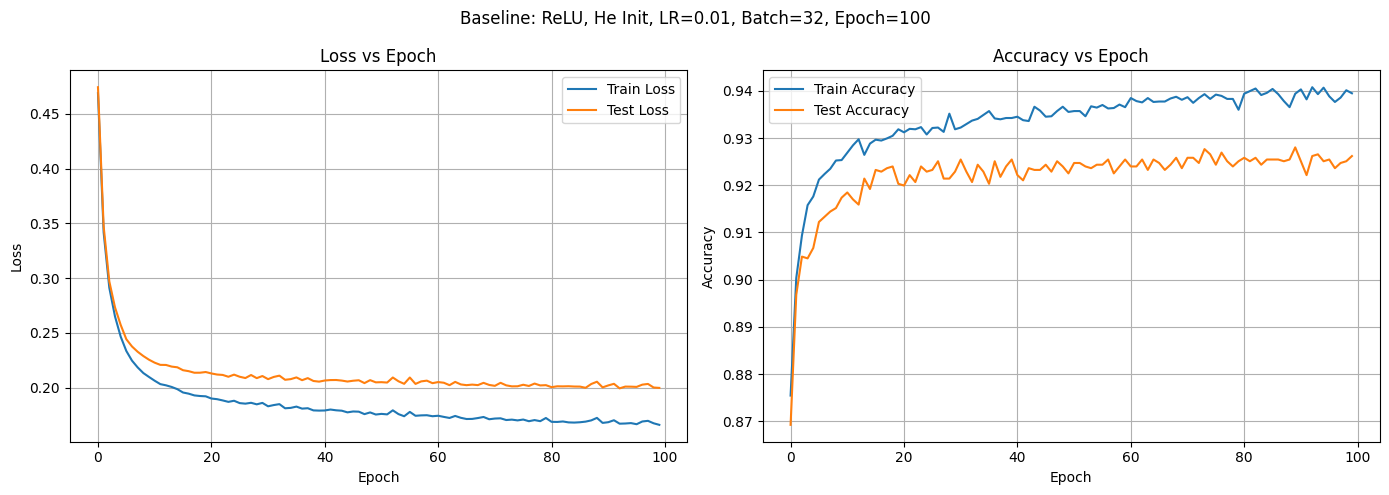

In [60]:
def plot_history(history, title="Training Results"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['test_loss'], label='Test Loss')
    ax1.set_title('Loss vs Epoch')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history['train_acc'], label='Train Accuracy')
    ax2.plot(history['test_acc'], label='Test Accuracy')
    ax2.set_title('Accuracy vs Epoch')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_history(history, "Baseline: ReLU, He Init, LR=0.01, Batch=32, Epoch=100")

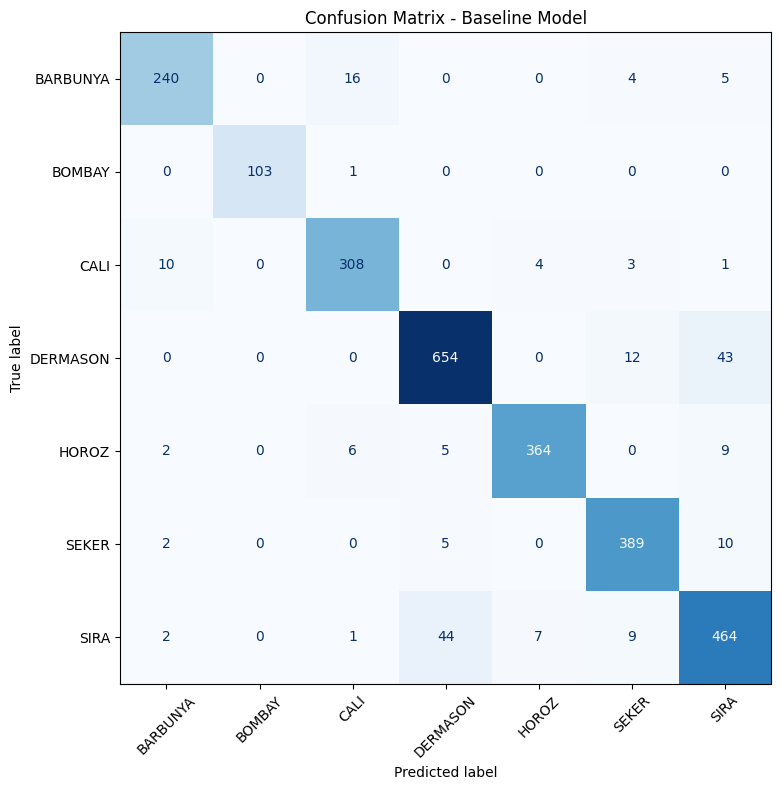

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
y_pred_class = np.argmax(y_pred, axis=1)
y_true_class = np.argmax(y_test, axis=1)

class_names = le.classes_

cm = confusion_matrix(y_true_class, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix - Baseline Model')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Eksperimen 1: Variasi Arsitektur (Depth & Width)
Menguji pengaruh jumlah hidden layer dan jumlah neuron terhadap akurasi model.

In [62]:
# Eksperimen 1: Variasi Arsitektur
eksperimen_arsitektur = [
    [16, 16, 7],           # 1 hidden layer, 16 neuron
    [16, 64, 7],           # 1 hidden layer, 64 neuron
    [16, 64, 32, 7],       # 2 hidden layer (baseline kita)
    [16, 128, 64, 32, 7],  # 3 hidden layer
]

labels = [
    "1 Layer - 16 neuron",
    "1 Layer - 64 neuron",
    "2 Layer - 64,32 neuron",
    "3 Layer - 128,64,32 neuron",
]

results_arsitektur = []

for arch, label in zip(eksperimen_arsitektur, labels):
    print(f"Training: {label}...")
    np.random.seed(42)
    model_exp = ANN(layer_sizes=arch, activation='relu', init_method='he', seed=42)
    hist = train(model_exp, X_train, y_train, X_test, y_test,
                 epochs=100, batch_size=32, learning_rate=0.01)

    results_arsitektur.append({
        'label': label,
        'train_acc': hist['train_acc'][-1],
        'test_acc': hist['test_acc'][-1],
        'train_loss': hist['train_loss'][-1],
        'test_loss': hist['test_loss'][-1],
        'history': hist
    })
    print(f"  Train Acc: {hist['train_acc'][-1]:.4f} | Test Acc: {hist['test_acc'][-1]:.4f}\n")

print("Eksperimen arsitektur selesai!")

Training: 1 Layer - 16 neuron...
Epoch 10/100 | Train Loss: 0.2377 | Test Loss: 0.2399 | Train Acc: 0.9213 | Test Acc: 0.9203
Epoch 20/100 | Train Loss: 0.2114 | Test Loss: 0.2155 | Train Acc: 0.9244 | Test Acc: 0.9225
Epoch 30/100 | Train Loss: 0.2033 | Test Loss: 0.2089 | Train Acc: 0.9264 | Test Acc: 0.9218
Epoch 40/100 | Train Loss: 0.1983 | Test Loss: 0.2044 | Train Acc: 0.9286 | Test Acc: 0.9225
Epoch 50/100 | Train Loss: 0.1956 | Test Loss: 0.2034 | Train Acc: 0.9285 | Test Acc: 0.9225
Epoch 60/100 | Train Loss: 0.1928 | Test Loss: 0.2016 | Train Acc: 0.9302 | Test Acc: 0.9243
Epoch 70/100 | Train Loss: 0.1911 | Test Loss: 0.2012 | Train Acc: 0.9307 | Test Acc: 0.9251
Epoch 80/100 | Train Loss: 0.1900 | Test Loss: 0.2002 | Train Acc: 0.9306 | Test Acc: 0.9266
Epoch 90/100 | Train Loss: 0.1884 | Test Loss: 0.1993 | Train Acc: 0.9307 | Test Acc: 0.9247
Epoch 100/100 | Train Loss: 0.1872 | Test Loss: 0.1993 | Train Acc: 0.9327 | Test Acc: 0.9251
  Train Acc: 0.9327 | Test Acc: 0.92

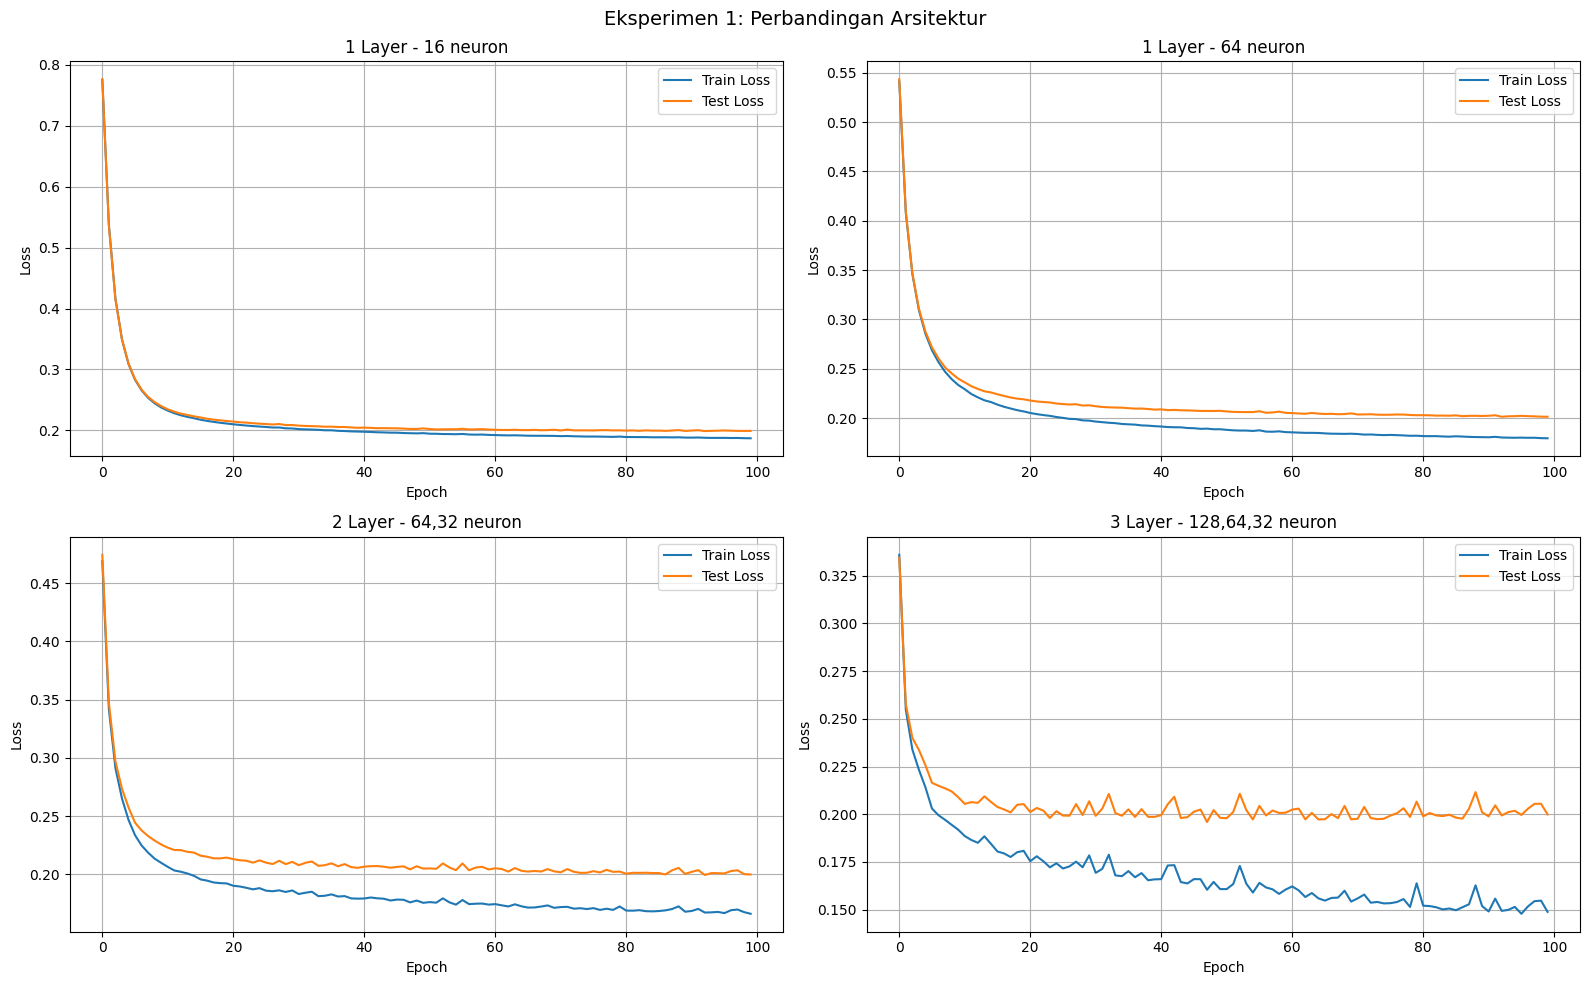


=== RINGKASAN EKSPERIMEN ARSITEKTUR ===
Arsitektur                      Train Acc   Test Acc   Train Loss  Test Loss
---------------------------------------------------------------------------
1 Layer - 16 neuron                0.9327     0.9251       0.1872     0.1993
1 Layer - 64 neuron                0.9344     0.9262       0.1796     0.2014
2 Layer - 64,32 neuron             0.9395     0.9262       0.1660     0.1998
3 Layer - 128,64,32 neuron         0.9441     0.9280       0.1489     0.1999


In [63]:
# Visualisasi perbandingan arsitektur
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, result in enumerate(results_arsitektur):
    ax = axes[i]
    ax.plot(result['history']['train_loss'], label='Train Loss')
    ax.plot(result['history']['test_loss'], label='Test Loss')
    ax.set_title(result['label'])
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True)

plt.suptitle('Eksperimen 1: Perbandingan Arsitektur', fontsize=14)
plt.tight_layout()
plt.show()

# Tabel ringkasan
print("\n=== RINGKASAN EKSPERIMEN ARSITEKTUR ===")
print(f"{'Arsitektur':<30} {'Train Acc':>10} {'Test Acc':>10} {'Train Loss':>12} {'Test Loss':>10}")
print("-" * 75)
for r in results_arsitektur:
    print(f"{r['label']:<30} {r['train_acc']:>10.4f} {r['test_acc']:>10.4f} {r['train_loss']:>12.4f} {r['test_loss']:>10.4f}")

## 5. Eksperimen 2: Variasi Inisialisasi Bobot
Membandingkan Zero, Random Uniform, Random Normal, Xavier, dan He initialization.

In [64]:
# Eksperimen 2: Inisialisasi Bobot
init_methods = ['zero', 'random_uniform', 'random_normal', 'xavier', 'he']
results_init = []

for method in init_methods:
    print(f"Training dengan inisialisasi: {method}...")
    np.random.seed(42)
    model_exp = ANN(
        layer_sizes=[16, 64, 32, 7],
        activation='relu',
        init_method=method,
        seed=42
    )
    hist = train(model_exp, X_train, y_train, X_test, y_test,
                 epochs=100, batch_size=32, learning_rate=0.01)

    results_init.append({
        'label': method,
        'train_acc': hist['train_acc'][-1],
        'test_acc': hist['test_acc'][-1],
        'train_loss': hist['train_loss'][-1],
        'test_loss': hist['test_loss'][-1],
        'history': hist
    })
    print(f"  Train Acc: {hist['train_acc'][-1]:.4f} | Test Acc: {hist['test_acc'][-1]:.4f}\n")

print("Eksperimen inisialisasi selesai!")

Training dengan inisialisasi: zero...
Epoch 10/100 | Train Loss: 1.8352 | Test Loss: 1.8352 | Train Acc: 0.2606 | Test Acc: 0.2604
Epoch 20/100 | Train Loss: 1.8345 | Test Loss: 1.8345 | Train Acc: 0.2606 | Test Acc: 0.2604
Epoch 30/100 | Train Loss: 1.8345 | Test Loss: 1.8345 | Train Acc: 0.2606 | Test Acc: 0.2604
Epoch 40/100 | Train Loss: 1.8345 | Test Loss: 1.8345 | Train Acc: 0.2606 | Test Acc: 0.2604
Epoch 50/100 | Train Loss: 1.8345 | Test Loss: 1.8345 | Train Acc: 0.2606 | Test Acc: 0.2604
Epoch 60/100 | Train Loss: 1.8345 | Test Loss: 1.8345 | Train Acc: 0.2606 | Test Acc: 0.2604
Epoch 70/100 | Train Loss: 1.8345 | Test Loss: 1.8345 | Train Acc: 0.2606 | Test Acc: 0.2604
Epoch 80/100 | Train Loss: 1.8345 | Test Loss: 1.8345 | Train Acc: 0.2606 | Test Acc: 0.2604
Epoch 90/100 | Train Loss: 1.8345 | Test Loss: 1.8345 | Train Acc: 0.2606 | Test Acc: 0.2604
Epoch 100/100 | Train Loss: 1.8345 | Test Loss: 1.8345 | Train Acc: 0.2606 | Test Acc: 0.2604
  Train Acc: 0.2606 | Test Acc:

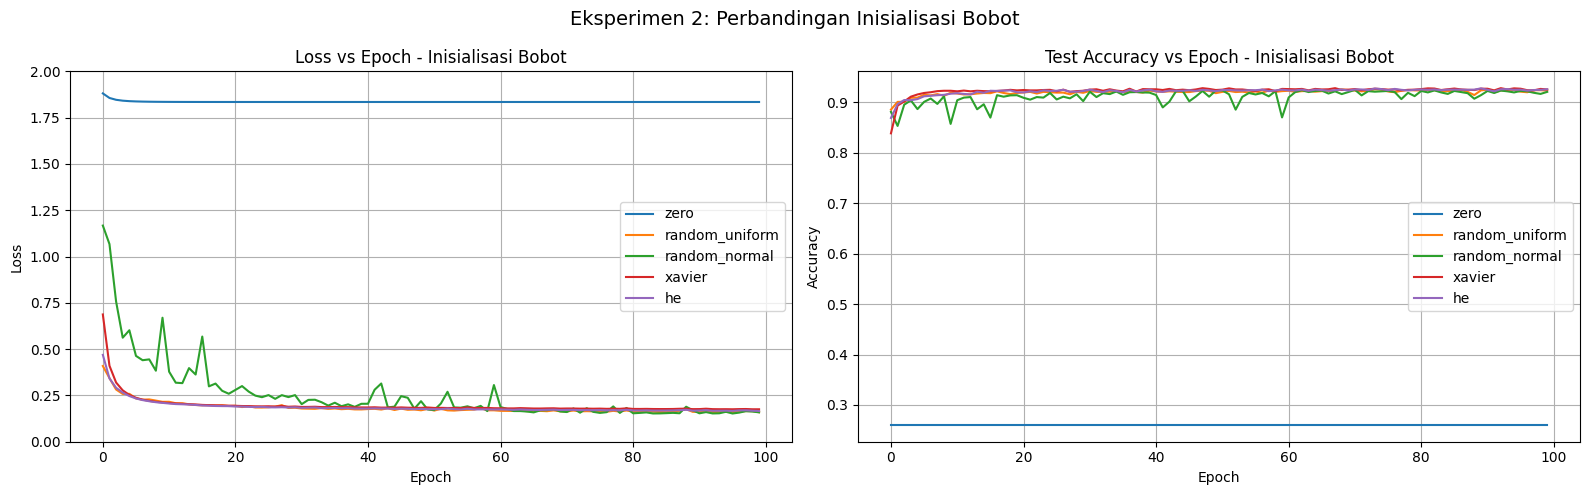


=== RINGKASAN INISIALISASI BOBOT ===
Method                Train Acc   Test Acc  Test Loss
-------------------------------------------------------
zero                     0.2606     0.2604     1.8345
random_uniform           0.9441     0.9236     0.2125
random_normal            0.9438     0.9210     0.2991
xavier                   0.9357     0.9258     0.1972
he                       0.9395     0.9262     0.1998


In [65]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for result in results_init:
    axes[0].plot(result['history']['train_loss'], label=result['label'])
    axes[1].plot(result['history']['test_acc'], label=result['label'])

axes[0].set_title('Loss vs Epoch - Inisialisasi Bobot')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)
axes[0].set_ylim(0, 2)

axes[1].set_title('Test Accuracy vs Epoch - Inisialisasi Bobot')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Eksperimen 2: Perbandingan Inisialisasi Bobot', fontsize=14)
plt.tight_layout()
plt.show()

print("\n=== RINGKASAN INISIALISASI BOBOT ===")
print(f"{'Method':<20} {'Train Acc':>10} {'Test Acc':>10} {'Test Loss':>10}")
print("-" * 55)
for r in results_init:
    print(f"{r['label']:<20} {r['train_acc']:>10.4f} {r['test_acc']:>10.4f} {r['test_loss']:>10.4f}")

## 6. Eksperimen 3: Variasi Fungsi Aktivasi
Membandingkan ReLU, Sigmoid, dan Tanh.

In [66]:
# Eksperimen 3: Fungsi Aktivasi
aktivasi_list = ['relu', 'sigmoid', 'tanh']
results_aktivasi = []

for act in aktivasi_list:
    print(f"Training dengan aktivasi: {act}...")
    np.random.seed(42)
    model_exp = ANN(
        layer_sizes=[16, 64, 32, 7],
        activation=act,
        init_method='he',
        seed=42
    )
    hist = train(model_exp, X_train, y_train, X_test, y_test,
                 epochs=100, batch_size=32, learning_rate=0.01)

    results_aktivasi.append({
        'label': act,
        'train_acc': hist['train_acc'][-1],
        'test_acc': hist['test_acc'][-1],
        'train_loss': hist['train_loss'][-1],
        'test_loss': hist['test_loss'][-1],
        'history': hist
    })
    print(f"  Train Acc: {hist['train_acc'][-1]:.4f} | Test Acc: {hist['test_acc'][-1]:.4f}\n")

print("Eksperimen aktivasi selesai!")

Training dengan aktivasi: relu...
Epoch 10/100 | Train Loss: 0.2098 | Test Loss: 0.2255 | Train Acc: 0.9253 | Test Acc: 0.9174
Epoch 20/100 | Train Loss: 0.1921 | Test Loss: 0.2143 | Train Acc: 0.9319 | Test Acc: 0.9203
Epoch 30/100 | Train Loss: 0.1861 | Test Loss: 0.2106 | Train Acc: 0.9319 | Test Acc: 0.9229
Epoch 40/100 | Train Loss: 0.1790 | Test Loss: 0.2055 | Train Acc: 0.9342 | Test Acc: 0.9254
Epoch 50/100 | Train Loss: 0.1755 | Test Loss: 0.2049 | Train Acc: 0.9355 | Test Acc: 0.9225
Epoch 60/100 | Train Loss: 0.1739 | Test Loss: 0.2041 | Train Acc: 0.9365 | Test Acc: 0.9254
Epoch 70/100 | Train Loss: 0.1711 | Test Loss: 0.2025 | Train Acc: 0.9381 | Test Acc: 0.9236
Epoch 80/100 | Train Loss: 0.1723 | Test Loss: 0.2023 | Train Acc: 0.9360 | Test Acc: 0.9251
Epoch 90/100 | Train Loss: 0.1678 | Test Loss: 0.2003 | Train Acc: 0.9394 | Test Acc: 0.9280
Epoch 100/100 | Train Loss: 0.1660 | Test Loss: 0.1998 | Train Acc: 0.9395 | Test Acc: 0.9262
  Train Acc: 0.9395 | Test Acc: 0.9

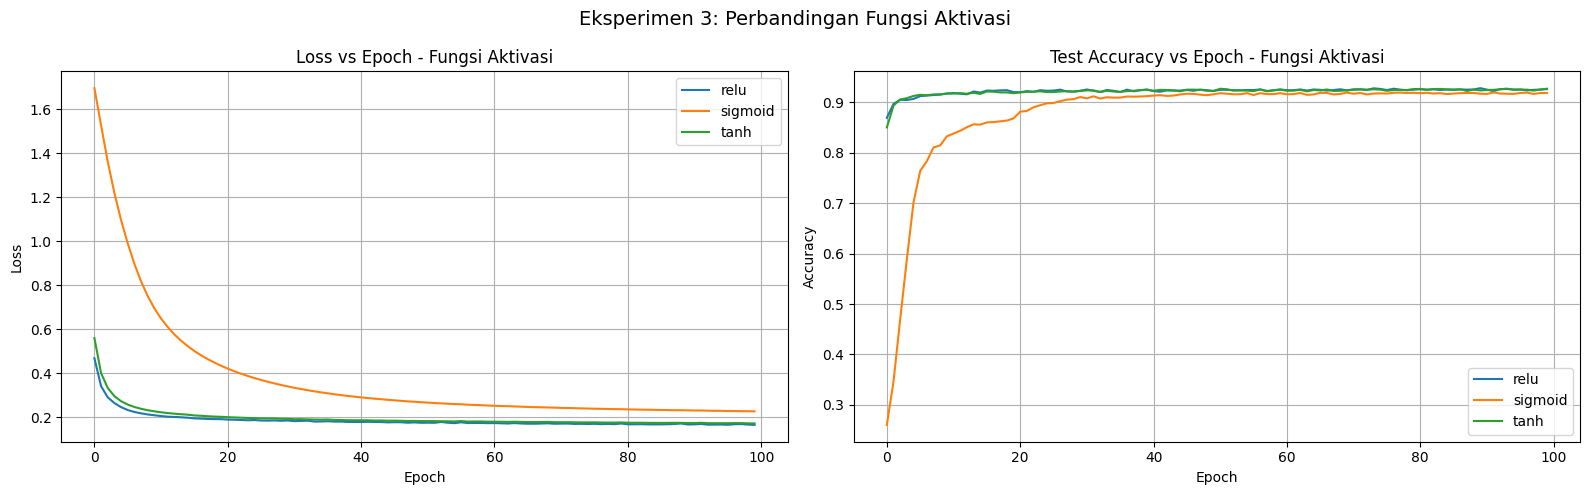


=== RINGKASAN FUNGSI AKTIVASI ===
Aktivasi      Train Acc   Test Acc   Train Loss  Test Loss
----------------------------------------------------------
relu             0.9395     0.9262       0.1660     0.1998
sigmoid          0.9217     0.9185       0.2277     0.2316
tanh             0.9374     0.9269       0.1727     0.2006


In [67]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for result in results_aktivasi:
    axes[0].plot(result['history']['train_loss'], label=result['label'])
    axes[1].plot(result['history']['test_acc'], label=result['label'])

axes[0].set_title('Loss vs Epoch - Fungsi Aktivasi')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Test Accuracy vs Epoch - Fungsi Aktivasi')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Eksperimen 3: Perbandingan Fungsi Aktivasi', fontsize=14)
plt.tight_layout()
plt.show()

print("\n=== RINGKASAN FUNGSI AKTIVASI ===")
print(f"{'Aktivasi':<12} {'Train Acc':>10} {'Test Acc':>10} {'Train Loss':>12} {'Test Loss':>10}")
print("-" * 58)
for r in results_aktivasi:
    print(f"{r['label']:<12} {r['train_acc']:>10.4f} {r['test_acc']:>10.4f} {r['train_loss']:>12.4f} {r['test_loss']:>10.4f}")

## 7. Eksperimen 4: Variasi Learning Rate
Membandingkan learning rate 0.1, 0.01, dan 0.001.

In [68]:
# Eksperimen 4: Learning Rate
learning_rates = [0.1, 0.01, 0.001]
results_lr = []

for lr in learning_rates:
    print(f"Training dengan learning rate: {lr}...")
    np.random.seed(42)
    model_exp = ANN(
        layer_sizes=[16, 64, 32, 7],
        activation='relu',
        init_method='he',
        seed=42
    )
    hist = train(model_exp, X_train, y_train, X_test, y_test,
                 epochs=100, batch_size=32, learning_rate=lr)

    results_lr.append({
        'label': f"LR={lr}",
        'train_acc': hist['train_acc'][-1],
        'test_acc': hist['test_acc'][-1],
        'train_loss': hist['train_loss'][-1],
        'test_loss': hist['test_loss'][-1],
        'history': hist
    })
    print(f"  Train Acc: {hist['train_acc'][-1]:.4f} | Test Acc: {hist['test_acc'][-1]:.4f}\n")

print("Eksperimen learning rate selesai!")

Training dengan learning rate: 0.1...
Epoch 10/100 | Train Loss: 0.2218 | Test Loss: 0.2477 | Train Acc: 0.9130 | Test Acc: 0.9133
Epoch 20/100 | Train Loss: 0.1797 | Test Loss: 0.2185 | Train Acc: 0.9364 | Test Acc: 0.9229
Epoch 30/100 | Train Loss: 0.1919 | Test Loss: 0.2314 | Train Acc: 0.9251 | Test Acc: 0.9174
Epoch 40/100 | Train Loss: 0.1546 | Test Loss: 0.2024 | Train Acc: 0.9431 | Test Acc: 0.9262
Epoch 50/100 | Train Loss: 0.1515 | Test Loss: 0.2053 | Train Acc: 0.9430 | Test Acc: 0.9262
Epoch 60/100 | Train Loss: 0.1861 | Test Loss: 0.2472 | Train Acc: 0.9307 | Test Acc: 0.9155
Epoch 70/100 | Train Loss: 0.1500 | Test Loss: 0.2141 | Train Acc: 0.9429 | Test Acc: 0.9254
Epoch 80/100 | Train Loss: 0.2036 | Test Loss: 0.2641 | Train Acc: 0.9246 | Test Acc: 0.9133
Epoch 90/100 | Train Loss: 0.1568 | Test Loss: 0.2327 | Train Acc: 0.9394 | Test Acc: 0.9218
Epoch 100/100 | Train Loss: 0.1390 | Test Loss: 0.2178 | Train Acc: 0.9447 | Test Acc: 0.9288
  Train Acc: 0.9447 | Test Acc:

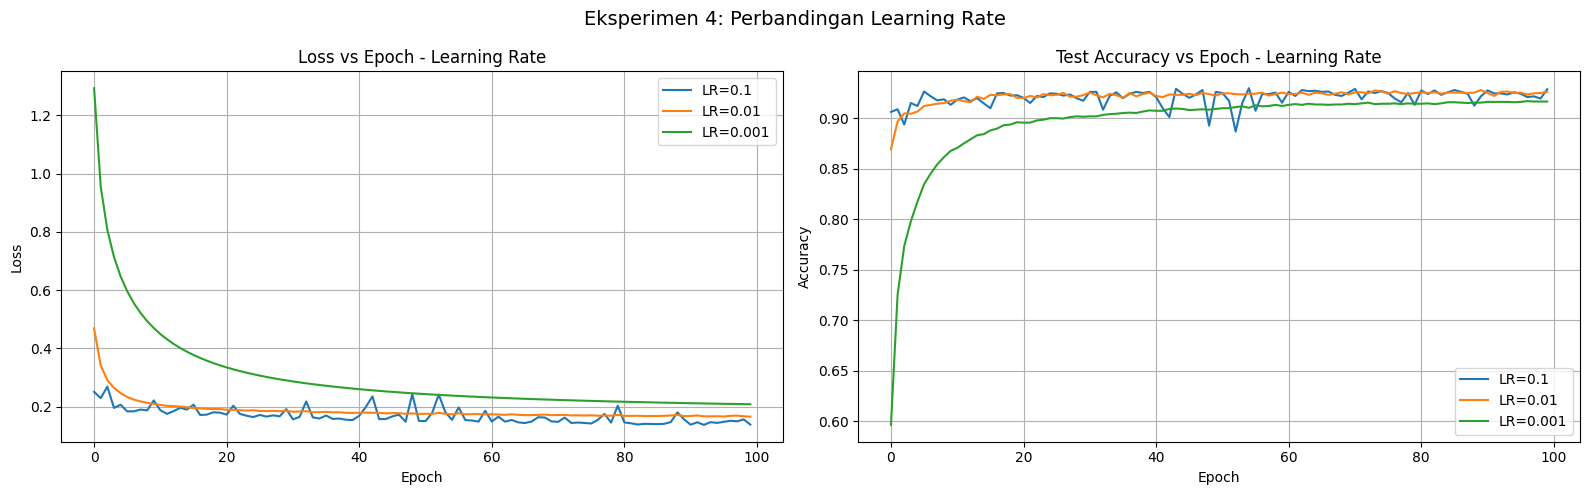


=== RINGKASAN LEARNING RATE ===
Learning Rate    Train Acc   Test Acc   Train Loss  Test Loss
------------------------------------------------------------
LR=0.1              0.9447     0.9288       0.1390     0.2178
LR=0.01             0.9395     0.9262       0.1660     0.1998
LR=0.001            0.9251     0.9166       0.2087     0.2246


In [69]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for result in results_lr:
    axes[0].plot(result['history']['train_loss'], label=result['label'])
    axes[1].plot(result['history']['test_acc'], label=result['label'])

axes[0].set_title('Loss vs Epoch - Learning Rate')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Test Accuracy vs Epoch - Learning Rate')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Eksperimen 4: Perbandingan Learning Rate', fontsize=14)
plt.tight_layout()
plt.show()

print("\n=== RINGKASAN LEARNING RATE ===")
print(f"{'Learning Rate':<15} {'Train Acc':>10} {'Test Acc':>10} {'Train Loss':>12} {'Test Loss':>10}")
print("-" * 60)
for r in results_lr:
    print(f"{r['label']:<15} {r['train_acc']:>10.4f} {r['test_acc']:>10.4f} {r['train_loss']:>12.4f} {r['test_loss']:>10.4f}")

## 8. Eksperimen 5: Variasi Batch Size
Membandingkan batch size 16, 32, dan 64.

In [70]:
# Eksperimen 5: Batch Size
batch_sizes = [16, 32, 64]
results_batch = []

for batch in batch_sizes:
    print(f"Training dengan batch size: {batch}...")
    np.random.seed(42)
    model_exp = ANN(
        layer_sizes=[16, 64, 32, 7],
        activation='relu',
        init_method='he',
        seed=42
    )
    hist = train(model_exp, X_train, y_train, X_test, y_test,
                 epochs=100, batch_size=batch, learning_rate=0.01)

    results_batch.append({
        'label': f"Batch={batch}",
        'train_acc': hist['train_acc'][-1],
        'test_acc': hist['test_acc'][-1],
        'train_loss': hist['train_loss'][-1],
        'test_loss': hist['test_loss'][-1],
        'history': hist
    })
    print(f"  Train Acc: {hist['train_acc'][-1]:.4f} | Test Acc: {hist['test_acc'][-1]:.4f}\n")

print("Eksperimen batch size selesai!")

Training dengan batch size: 16...
Epoch 10/100 | Train Loss: 0.1919 | Test Loss: 0.2137 | Train Acc: 0.9294 | Test Acc: 0.9236
Epoch 20/100 | Train Loss: 0.1818 | Test Loss: 0.2092 | Train Acc: 0.9355 | Test Acc: 0.9232
Epoch 30/100 | Train Loss: 0.1774 | Test Loss: 0.2062 | Train Acc: 0.9355 | Test Acc: 0.9232
Epoch 40/100 | Train Loss: 0.1705 | Test Loss: 0.2015 | Train Acc: 0.9372 | Test Acc: 0.9258
Epoch 50/100 | Train Loss: 0.1669 | Test Loss: 0.2008 | Train Acc: 0.9405 | Test Acc: 0.9243
Epoch 60/100 | Train Loss: 0.1659 | Test Loss: 0.2012 | Train Acc: 0.9389 | Test Acc: 0.9258
Epoch 70/100 | Train Loss: 0.1626 | Test Loss: 0.1990 | Train Acc: 0.9403 | Test Acc: 0.9262
Epoch 80/100 | Train Loss: 0.1633 | Test Loss: 0.1984 | Train Acc: 0.9393 | Test Acc: 0.9262
Epoch 90/100 | Train Loss: 0.1602 | Test Loss: 0.1988 | Train Acc: 0.9404 | Test Acc: 0.9277
Epoch 100/100 | Train Loss: 0.1582 | Test Loss: 0.1983 | Train Acc: 0.9415 | Test Acc: 0.9266
  Train Acc: 0.9415 | Test Acc: 0.9

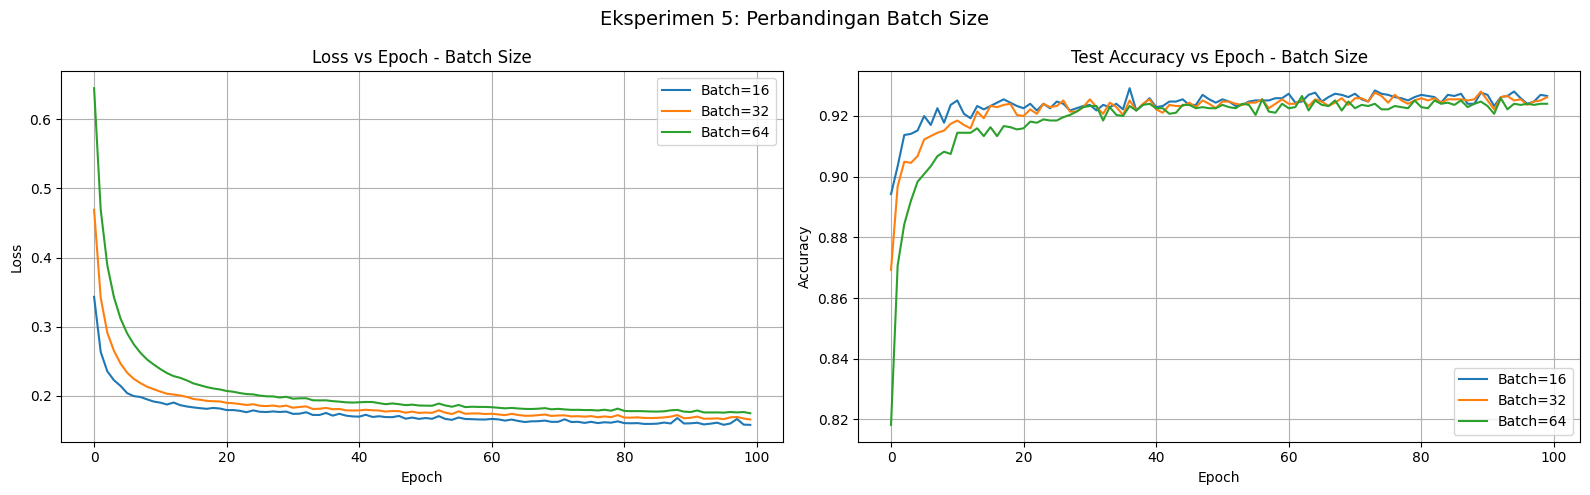


=== RINGKASAN BATCH SIZE ===
Batch Size    Train Acc   Test Acc   Train Loss  Test Loss
----------------------------------------------------------
Batch=16         0.9415     0.9266       0.1582     0.1983
Batch=32         0.9395     0.9262       0.1660     0.1998
Batch=64         0.9360     0.9240       0.1750     0.2040


In [71]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for result in results_batch:
    axes[0].plot(result['history']['train_loss'], label=result['label'])
    axes[1].plot(result['history']['test_acc'], label=result['label'])

axes[0].set_title('Loss vs Epoch - Batch Size')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Test Accuracy vs Epoch - Batch Size')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Eksperimen 5: Perbandingan Batch Size', fontsize=14)
plt.tight_layout()
plt.show()

print("\n=== RINGKASAN BATCH SIZE ===")
print(f"{'Batch Size':<12} {'Train Acc':>10} {'Test Acc':>10} {'Train Loss':>12} {'Test Loss':>10}")
print("-" * 58)
for r in results_batch:
    print(f"{r['label']:<12} {r['train_acc']:>10.4f} {r['test_acc']:>10.4f} {r['train_loss']:>12.4f} {r['test_loss']:>10.4f}")

## 9. Eksperimen 6: Variasi Jumlah Epoch
Membandingkan epoch 50, 100, dan 200.

In [72]:
# Eksperimen 6: Jumlah Epoch
epoch_list = [50, 100, 200]
results_epoch = []

for ep in epoch_list:
    print(f"Training dengan epoch: {ep}...")
    np.random.seed(42)
    model_exp = ANN(
        layer_sizes=[16, 64, 32, 7],
        activation='relu',
        init_method='he',
        seed=42
    )
    hist = train(model_exp, X_train, y_train, X_test, y_test,
                 epochs=ep, batch_size=32, learning_rate=0.01)

    results_epoch.append({
        'label': f"Epoch={ep}",
        'train_acc': hist['train_acc'][-1],
        'test_acc': hist['test_acc'][-1],
        'train_loss': hist['train_loss'][-1],
        'test_loss': hist['test_loss'][-1],
        'history': hist
    })
    print(f"  Train Acc: {hist['train_acc'][-1]:.4f} | Test Acc: {hist['test_acc'][-1]:.4f}\n")

print("Eksperimen epoch selesai!")

Training dengan epoch: 50...
Epoch 10/50 | Train Loss: 0.2098 | Test Loss: 0.2255 | Train Acc: 0.9253 | Test Acc: 0.9174
Epoch 20/50 | Train Loss: 0.1921 | Test Loss: 0.2143 | Train Acc: 0.9319 | Test Acc: 0.9203
Epoch 30/50 | Train Loss: 0.1861 | Test Loss: 0.2106 | Train Acc: 0.9319 | Test Acc: 0.9229
Epoch 40/50 | Train Loss: 0.1790 | Test Loss: 0.2055 | Train Acc: 0.9342 | Test Acc: 0.9254
Epoch 50/50 | Train Loss: 0.1755 | Test Loss: 0.2049 | Train Acc: 0.9355 | Test Acc: 0.9225
  Train Acc: 0.9355 | Test Acc: 0.9225

Training dengan epoch: 100...
Epoch 10/100 | Train Loss: 0.2098 | Test Loss: 0.2255 | Train Acc: 0.9253 | Test Acc: 0.9174
Epoch 20/100 | Train Loss: 0.1921 | Test Loss: 0.2143 | Train Acc: 0.9319 | Test Acc: 0.9203
Epoch 30/100 | Train Loss: 0.1861 | Test Loss: 0.2106 | Train Acc: 0.9319 | Test Acc: 0.9229
Epoch 40/100 | Train Loss: 0.1790 | Test Loss: 0.2055 | Train Acc: 0.9342 | Test Acc: 0.9254
Epoch 50/100 | Train Loss: 0.1755 | Test Loss: 0.2049 | Train Acc: 0.

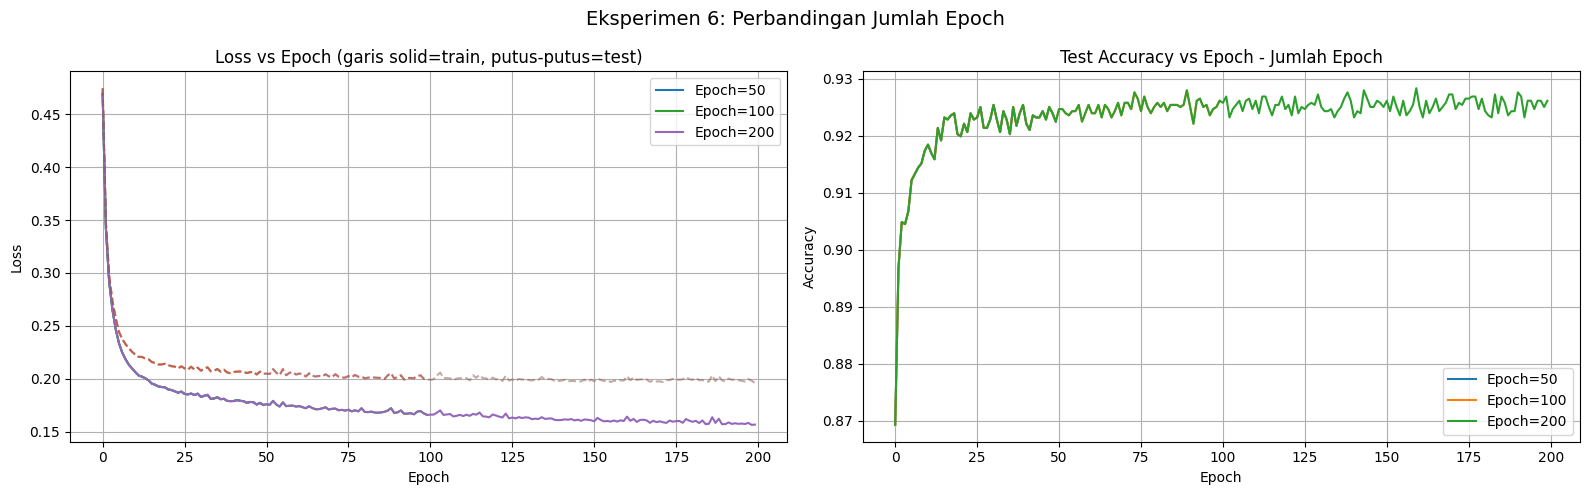


=== RINGKASAN JUMLAH EPOCH ===
Epoch         Train Acc   Test Acc   Train Loss  Test Loss
----------------------------------------------------------
Epoch=50         0.9355     0.9225       0.1755     0.2049
Epoch=100        0.9395     0.9262       0.1660     0.1998
Epoch=200        0.9423     0.9262       0.1569     0.1964


In [73]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for result in results_epoch:
    axes[0].plot(result['history']['train_loss'], label=result['label'])
    axes[0].plot(result['history']['test_loss'], linestyle='--', alpha=0.5)
    axes[1].plot(result['history']['test_acc'], label=result['label'])

axes[0].set_title('Loss vs Epoch (garis solid=train, putus-putus=test)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Test Accuracy vs Epoch - Jumlah Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Eksperimen 6: Perbandingan Jumlah Epoch', fontsize=14)
plt.tight_layout()
plt.show()

print("\n=== RINGKASAN JUMLAH EPOCH ===")
print(f"{'Epoch':<12} {'Train Acc':>10} {'Test Acc':>10} {'Train Loss':>12} {'Test Loss':>10}")
print("-" * 58)
for r in results_epoch:
    print(f"{r['label']:<12} {r['train_acc']:>10.4f} {r['test_acc']:>10.4f} {r['train_loss']:>12.4f} {r['test_loss']:>10.4f}")

## 10. Implementasi Menggunakan Keras
Membangun model ANN dengan arsitektur yang sama menggunakan TensorFlow/Keras untuk perbandingan.

In [74]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set seed untuk reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Bangun model Keras - arsitektur SAMA dengan baseline from scratch
model_keras = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(16,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(7, activation='softmax')
])

# Kompilasi model
model_keras.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01),  # samakan dengan mini-batch GD
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Lihat summary arsitektur
model_keras.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,399 (13.28 KB)

 Trainable params: 3,399 (13.28 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
# Training model Keras
history_keras = model_keras.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

print("\nTraining Keras selesai!")
print(f"Akurasi akhir - Train: {history_keras.history['accuracy'][-1]:.4f} | Test: {history_keras.history['val_accuracy'][-1]:.4f}")

Epoch 1/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6331 - loss: 1.0701 - val_accuracy: 0.7936 - val_loss: 0.6781
Epoch 2/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8591 - loss: 0.5312 - val_accuracy: 0.8817 - val_loss: 0.4279
Epoch 3/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8968 - loss: 0.3752 - val_accuracy: 0.9001 - val_loss: 0.3357
Epoch 4/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9079 - loss: 0.3093 - val_accuracy: 0.9104 - val_loss: 0.2907
Epoch 5/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9158 - loss: 0.2741 - val_accuracy: 0.9130 - val_loss: 0.2646
Epoch 6/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9179 - loss: 0.2527 - val_accuracy: 0.9155 - val_loss: 0.2483
Epoch 7/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9202 - loss: 0.2388 - val_accuracy: 0.9192 - val_loss: 0.2378
Epoch 8/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9220 - loss: 0.2295 - val_accu

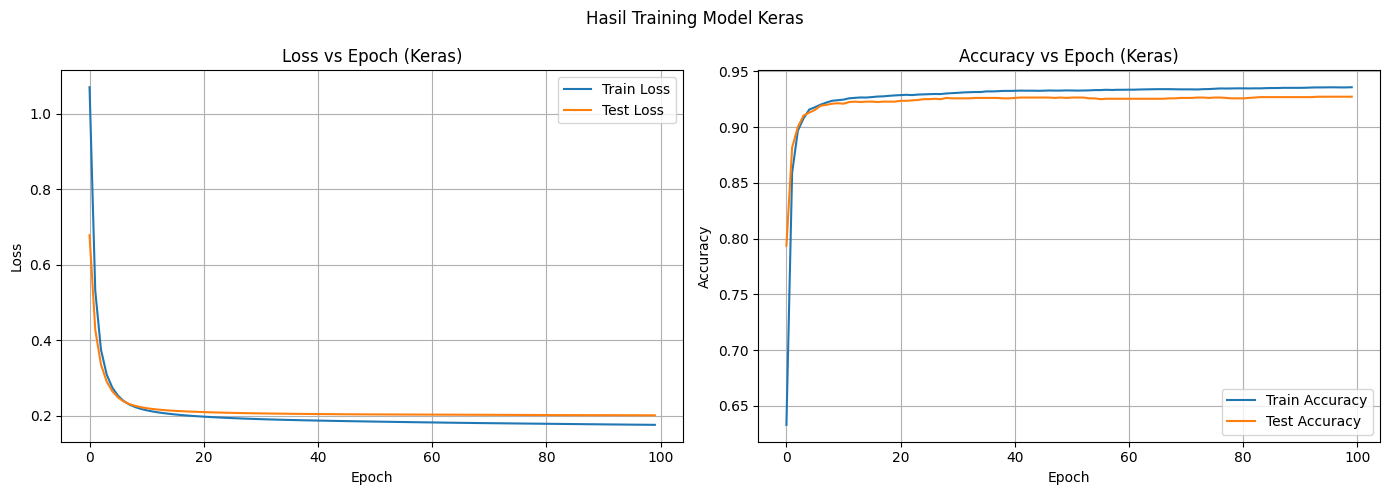

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


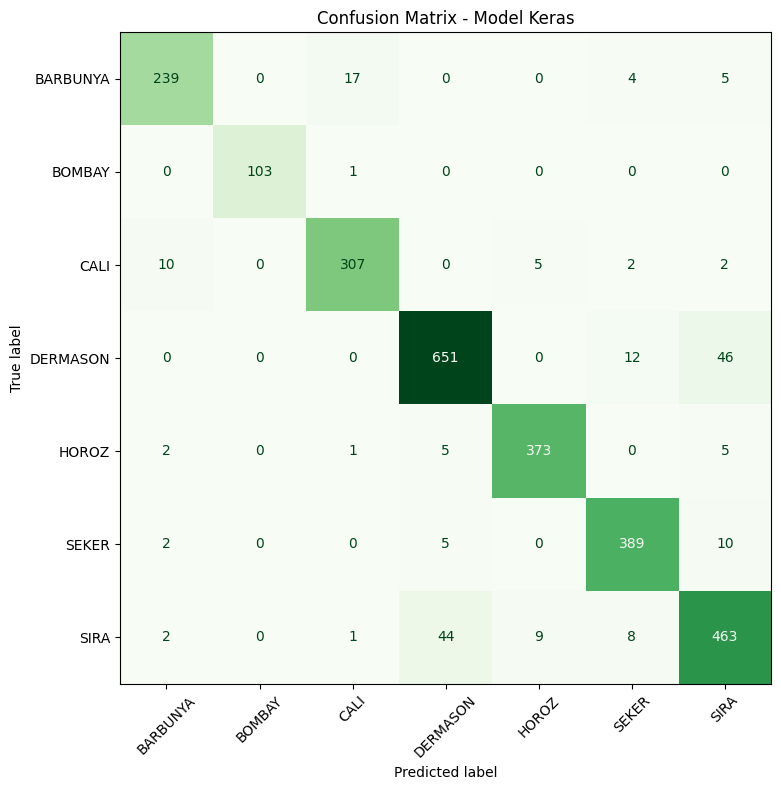

In [76]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_keras.history['loss'], label='Train Loss')
ax1.plot(history_keras.history['val_loss'], label='Test Loss')
ax1.set_title('Loss vs Epoch (Keras)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(history_keras.history['accuracy'], label='Train Accuracy')
ax2.plot(history_keras.history['val_accuracy'], label='Test Accuracy')
ax2.set_title('Accuracy vs Epoch (Keras)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.suptitle('Hasil Training Model Keras')
plt.tight_layout()
plt.show()

# Confusion Matrix Keras
y_pred_keras = model_keras.predict(X_test)
y_pred_keras_class = np.argmax(y_pred_keras, axis=1)
y_true_class = np.argmax(y_test, axis=1)

cm_keras = confusion_matrix(y_true_class, y_pred_keras_class)
disp_keras = ConfusionMatrixDisplay(confusion_matrix=cm_keras, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp_keras.plot(ax=ax, cmap='Greens', colorbar=False)
plt.title('Confusion Matrix - Model Keras')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. Perbandingan dengan Sklearn (MLPClassifier)
Membandingkan hasil model from scratch dan Keras dengan library sklearn.

In [77]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Sklearn pakai label encoded (bukan one-hot)
y_train_sklearn = np.argmax(y_train, axis=1)
y_test_sklearn = np.argmax(y_test, axis=1)

# Model MLPClassifier - arsitektur sama
model_sklearn = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='sgd',
    learning_rate_init=0.01,
    batch_size=32,
    max_iter=100,
    random_state=42
)

model_sklearn.fit(X_train, y_train_sklearn)

y_pred_sklearn = model_sklearn.predict(X_test)
acc_sklearn = accuracy_score(y_test_sklearn, y_pred_sklearn)

print(f"Akurasi sklearn MLPClassifier: {acc_sklearn:.4f}")
print(f"\nPerbandingan akhir:")
print(f"From Scratch : 0.9262")
print(f"Keras        : 0.9262")
print(f"Sklearn      : {acc_sklearn:.4f}")

Akurasi sklearn MLPClassifier: 0.9225

Perbandingan akhir:
From Scratch : 0.9262
Keras        : 0.9262
Sklearn      : 0.9225


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
